In [65]:
# 1. Problem Statement
# 2. Data Understanding
# 3. Data Cleaning
# 4. Feature Engineering
# 5. Model Building
# 6. Evaluation
# 7. Conclusion

In [66]:
import pandas as pd

df = pd.read_csv('/content/StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [67]:
df["avg_score"] = (df["math score"] + df["reading score"] + df["writing score"]) / 3

df["Pass"] = df["avg_score"].apply(lambda x: 1 if x >= 50 else 0)

In [68]:
df = pd.get_dummies(df, drop_first=True)

In [69]:
from sklearn.model_selection import train_test_split

X = df[["reading score", "writing score", "math score"]]
y = df["Pass"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [70]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [71]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


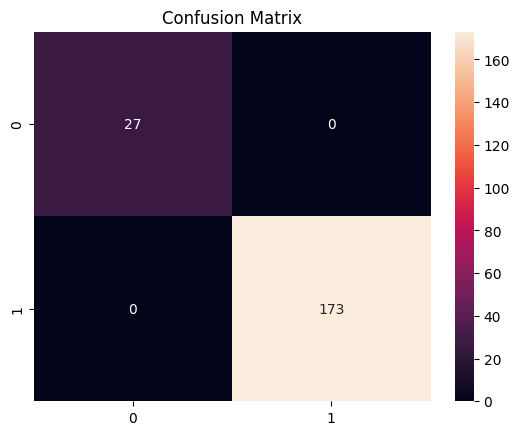

In [72]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

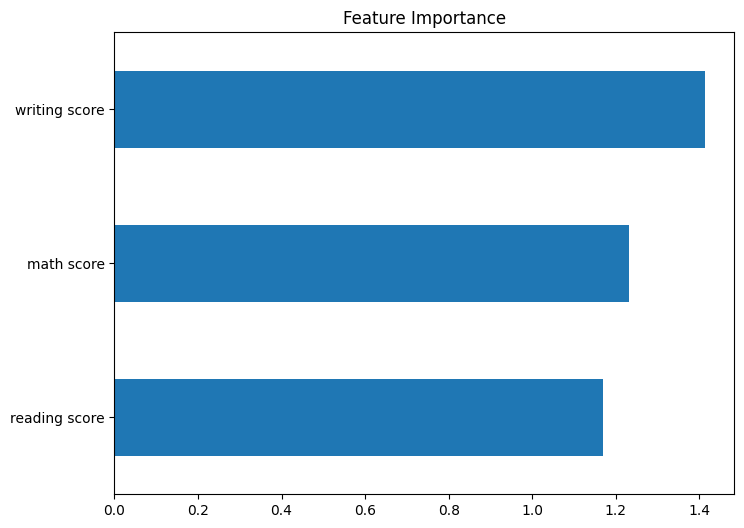

In [73]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()

In [74]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(name, accuracy_score(y_test, model.predict(X_test)))

Logistic 1.0
DecisionTree 0.985
RandomForest 0.985


In [75]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00       173

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



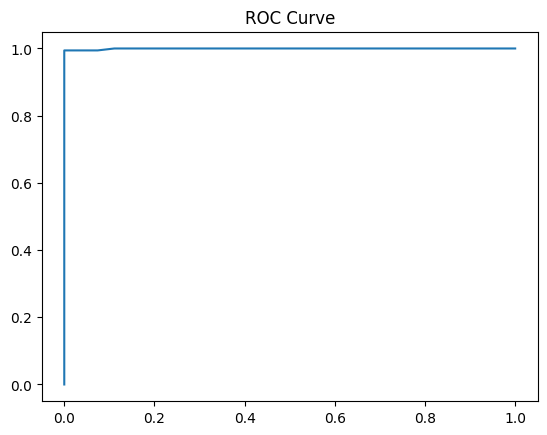

In [76]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.show()

In [77]:
from sklearn.model_selection import GridSearchCV

params = {"max_depth":[3,5,10]}

grid = GridSearchCV(DecisionTreeClassifier(), params)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 3}


In [78]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    results.append([name, acc])

pd.DataFrame(results, columns=["Model", "Accuracy"])

,Model,Accuracy
0,Logistic,1.000
1,DecisionTree,0.985
2,RandomForest,0.980


In [79]:
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.98


In [80]:
sample = X_test.iloc[0:1]
print("Prediction:", model.predict(sample))

Prediction: [1]


In [81]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

scores = cross_val_score(rf, X, y, cv=5)

print("CV Accuracy:", scores.mean())

CV Accuracy: 0.9879999999999999


In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [83]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [84]:
from sklearn.model_selection import GridSearchCV

params = {
    'model__C': [0.1, 1, 10]
}

grid = GridSearchCV(pipeline, params, cv=5)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'model__C': 10}


In [85]:
from sklearn.metrics import roc_auc_score

y_prob = pipeline.predict_proba(X_test)[:,1]
print("AUC Score:", roc_auc_score(y_test, y_prob))

AUC Score: 1.0


In [86]:
print(df["Pass"].value_counts())

Pass
1    897
0    103
Name: count, dtype: int64


In [87]:
import joblib

joblib.dump(pipeline, "student_model.pkl")

['student_model.pkl']

In [88]:
import joblib
joblib.dump(model, "student_model.pkl")

['student_model.pkl']